In [20]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

In [2]:
DATA_DIR = Path("../dataset") 
train = DATA_DIR / "train"
test = DATA_DIR / "test"

train_s1 = pd.read_csv(train/ "train_source1.tsv", sep="\t")
train_s2 = pd.read_csv(train/ "train_source2.tsv", sep="\t")
train_s3 = pd.read_csv(train/ "train_source3.tsv", sep="\t")
gt = pd.read_csv(train/ "train_ground_truth.tsv", sep="\t")

test_s1 = pd.read_csv(test/ "test_source1.tsv", sep="\t")
test_s2 = pd.read_csv(test / "test_source2.tsv", sep="\t")
test_s3 = pd.read_csv(test / "test_source3.tsv", sep="\t")

for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3),
                  ("gt", gt), ("test_s1", test_s1), ("test_s2", test_s2), ("test_s3", test_s3)]:
    print(f"{name:10s} shape={df.shape}")


train_s1   shape=(2206821, 4)
train_s2   shape=(5034616, 4)
train_s3   shape=(5285603, 4)
gt         shape=(2206821, 2)
test_s1    shape=(1732544, 4)
test_s2    shape=(4887273, 4)
test_s3    shape=(5082316, 4)


In [3]:
assert train_s1.shape[1] == 4, "Expected 4 columns (entity_id, business_name, business_address, country) — check the separator."
train_s1.head()

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


In [4]:
for name, df in [("train_s1", train_s1), ("train_s2", train_s2), ("train_s3", train_s3)]:
    print(f"--- {name} ---")
    print(df.isna().sum())
    print(df.dtypes)
    print()
    

--- train_s1 ---
entity_id           0
business_name       0
business_address    0
country             0
dtype: int64
entity_id           object
business_name       object
business_address    object
country             object
dtype: object

--- train_s2 ---
entity_id                0
business_name            2
business_address    168967
country                  0
dtype: int64
entity_id           object
business_name       object
business_address    object
country             object
dtype: object

--- train_s3 ---
entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64
entity_id           object
business_name       object
business_address    object
country             object
dtype: object



In [5]:
pd.set_option("display.max_rows", None)
print(train_s3.isna().sum())
print(train_s3.dtypes)

entity_id                0
business_name           13
business_address    175916
country                  0
dtype: int64
entity_id           object
business_name       object
business_address    object
country             object
dtype: object


## 3. entity_id prefix sanity

In [6]:
def check_ids(df, prefix, name):
    bad_prefix = (~df["entity_id"].str.startswith(prefix)).sum()
    dupes = df["entity_id"].duplicated().sum()
    print(f"{name}: bad_prefix={bad_prefix}, duplicate_ids={dupes}, n={len(df)}")

check_ids(train_s1, "S1-", "train_s1")
check_ids(train_s2, "S2-", "train_s2")
check_ids(train_s3, "S3-", "train_s3")
check_ids(test_s1, "S1-", "test_s1")
check_ids(test_s2, "S2-", "test_s2")
check_ids(test_s3, "S3-", "test_s3")

train_s1: bad_prefix=0, duplicate_ids=0, n=2206821
train_s2: bad_prefix=0, duplicate_ids=0, n=5034616
train_s3: bad_prefix=0, duplicate_ids=0, n=5285603
test_s1: bad_prefix=0, duplicate_ids=0, n=1732544
test_s2: bad_prefix=0, duplicate_ids=0, n=4887273
test_s3: bad_prefix=0, duplicate_ids=0, n=5082316


In [9]:
print("TRAIN country counts (S3):")
print(train_s1["country"].value_counts(dropna=False))
print()
print("TEST country counts (S3):")
print(test_s1["country"].value_counts(dropna=False))    


TRAIN country counts (S3):
country
US       1323633
India     883188
Name: count, dtype: int64

TEST country counts (S3):
country
India     809986
US        663106
France    259452
Name: count, dtype: int64


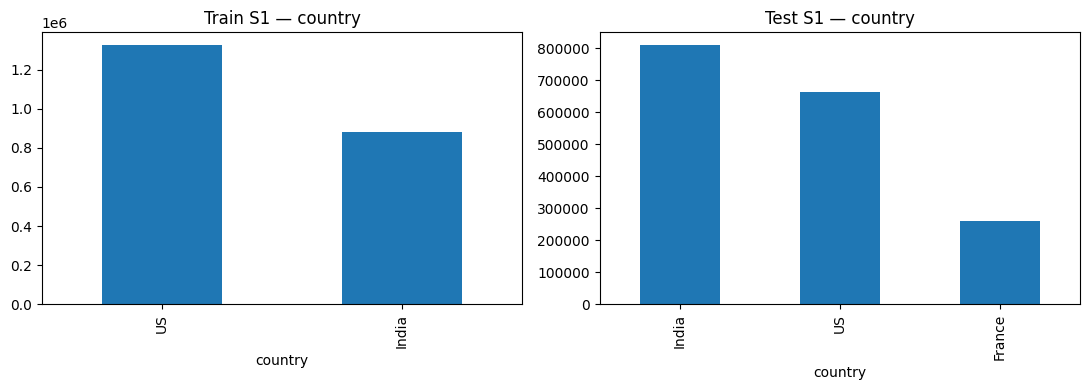

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_s1["country"].value_counts().plot(kind="bar", ax=axes[0], title="Train S1 — country")
test_s1["country"].value_counts().plot(kind="bar", ax=axes[1], title="Test S1 — country")
plt.tight_layout()
plt.show()


In [15]:
gt_filled = gt["matched_entity_ids"].fillna("")
match_counts = gt_filled.apply(lambda x: 0 if x == "" else len(x.split(",")))

print("Match count distribution per S1 entity:")
print(match_counts.value_counts().sort_index())
print()
print(f"Singleton rate (0 matches): {(match_counts == 0).mean():.2%}")
print(f"Mean matches per entity (incl. singletons): {match_counts.mean():.3f}")
print(f"Max matches for a single entity: {match_counts.max()}")



Match count distribution per S1 entity:
matched_entity_ids
0     123247
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37
Name: count, dtype: int64

Singleton rate (0 matches): 5.58%
Mean matches per entity (incl. singletons): 3.461
Max matches for a single entity: 11


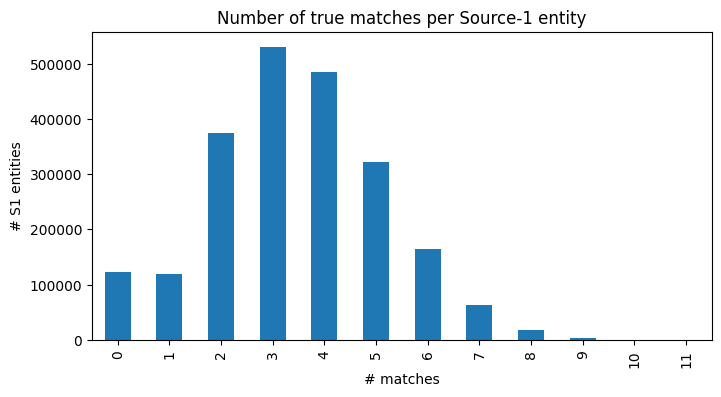

In [16]:
match_counts.value_counts().sort_index().plot(kind="bar", figsize=(8,4),
    title="Number of true matches per Source-1 entity")
plt.xlabel("# matches")
plt.ylabel("# S1 entities")
plt.show()

In [17]:
# Split: how many matches come from S2 vs S3?
def split_source_counts(id_list_str):
    if not isinstance(id_list_str, str) or id_list_str == "":
        return 0, 0
    ids = id_list_str.split(",")
    s2 = sum(1 for i in ids if i.startswith("S2-"))
    s3 = sum(1 for i in ids if i.startswith("S3-"))
    return s2, s3

counts = gt_filled.apply(split_source_counts)
s2_counts = counts.apply(lambda x: x[0])
s3_counts = counts.apply(lambda x: x[1])
print(f"Total S2 matches: {s2_counts.sum()}   Total S3 matches: {s3_counts.sum()}")
print(f"Entities with >=1 S2 match: {(s2_counts > 0).mean():.2%}")
print(f"Entities with >=1 S3 match: {(s3_counts > 0).mean():.2%}")


Total S2 matches: 3693619   Total S3 matches: 3944746
Entities with >=1 S2 match: 86.96%
Entities with >=1 S3 match: 87.93%


In [18]:
for name, df in [("S1", train_s1), ("S2", train_s2), ("S3", train_s3)]:
    name_len = df["business_name"].astype(str).str.len()
    addr_len = df["business_address"].astype(str).str.len()
    print(f"{name}: name_len mean={name_len.mean():.1f} (min={name_len.min()}, max={name_len.max()}) | "
          f"addr_len mean={addr_len.mean():.1f} (min={addr_len.min()}, max={addr_len.max()})")


S1: name_len mean=24.0 (min=3, max=105) | addr_len mean=52.1 (min=11, max=256)
S2: name_len mean=25.1 (min=2, max=104) | addr_len mean=46.3 (min=3, max=249)
S3: name_len mean=25.2 (min=2, max=123) | addr_len mean=46.8 (min=2, max=240)


In [19]:
s1_lookup = train_s1.set_index("entity_id")
s2_lookup = train_s2.set_index("entity_id")
s3_lookup = train_s3.set_index("entity_id")

def lookup(entity_id):
    if entity_id.startswith("S1-"):
        return s1_lookup.loc[entity_id]
    elif entity_id.startswith("S2-"):
        return s2_lookup.loc[entity_id]
    elif entity_id.startswith("S3-"):
        return s3_lookup.loc[entity_id]

sample_rows = gt[gt["matched_entity_ids"].notna() & (gt["matched_entity_ids"] != "")].sample(15, random_state=42)

for _, row in sample_rows.iterrows():
    s1_id = row["source1_entity_id"]
    s1_rec = lookup(s1_id)
    print(f"S1  [{s1_id}] {s1_rec['business_name']!r} | {s1_rec['business_address']!r} | {s1_rec['country']}")
    for mid in row["matched_entity_ids"].split(","):
        rec = lookup(mid)
        print(f"  -> [{mid}] {rec['business_name']!r} | {rec['business_address']!r} | {rec['country']}")
    print()



S1  [S1-777210964] 'Davis Family Office' | '88 Olive Circle, Lebanon, TN' | US
  -> [S2-12029274] 'Davis Family Offie' | '88 OLIVE CIR, LEBANON, TN' | US
  -> [S2-407524980] 'DAVIS FAMILY OFFICE' | 'OLIVE CIR, LEBANON, TN' | US
  -> [S3-970714334] 'Davis Family (Office)' | '88 Olive Cir, Lebanon, Tennessee' | US
  -> [S3-712922821] 'Davis Family' | 'Lebanon, Tennessee, 88 Olive Cir' | US

S1  [S1-190133982] 'MS Consultancy Corp' | 'Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli, Pune, Maharashtra' | India
  -> [S2-523219173] 'MS [Consultancy]' | 'SHYMALA APPTS 1-1ST FLOOR FLAT NO. 4 OPP RATNA HOSPITAL SB ROAD IN HAVELI, PUNE, Maharashtra' | India
  -> [S3-716445195] 'M5  Consultancy Corp' | 'Pune, MH, Pune, Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli' | India
  -> [S3-986804760] 'MS Corp Services' | 'Shymala Appts 1St Floor Flat No. 4 Opp Ratna Hospital Sb Road In Haveli, Pune, MH' | India

S1  [S1-970131671] '3520 Main Road Realty I

In [21]:
def normalize_name(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_s1["name_norm"] = train_s1["business_name"].apply(normalize_name)
train_s2["name_norm"] = train_s2["business_name"].apply(normalize_name)
train_s3["name_norm"] = train_s3["business_name"].apply(normalize_name)

s2_by_name = train_s2.groupby("name_norm")["entity_id"].apply(set).to_dict()
s3_by_name = train_s3.groupby("name_norm")["entity_id"].apply(set).to_dict()


In [23]:

s1_name_lookup = train_s1.set_index("entity_id")["name_norm"].to_dict()

hit, total = 0, 0

for row in gt.itertuples(index=False):
    truth = row.matched_entity_ids
    if not isinstance(truth, str) or truth == "":
        continue
    true_ids = set(truth.split(","))
    total += len(true_ids)

    name_norm = s1_name_lookup.get(row.source1_entity_id)
    if name_norm is None:
        continue
    candidates = s2_by_name.get(name_norm, set()) | s3_by_name.get(name_norm, set())
    hit += len(true_ids & candidates)

print(f"Naive exact-normalized-name recall: {hit}/{total} = {hit/total:.2%}")

Naive exact-normalized-name recall: 1668793/7638365 = 21.85%
